## 3DoF Entry VTOL w/o Aoa SCP

Imports

In [1]:
# Basic imports
import importlib
import numpy                as np
import matplotlib.pyplot    as plt
import pandas               as pd
import copy

# Trajopt imports --> pip install -e ~/ACL/trajopt
import trajopt; importlib.reload(trajopt)
import trajopt.core.modules.method.scp              as scp
import trajopt.core.problem                         as prob
import trajopt.utils.config_loader                  as cfg
import trajopt.utils.tools                          as tools
import trajopt.analysis.default_analysis            as default_analysis
import trajopt.analysis.statistics                  as stats
import trajopt.core.modules.analysis.monte_carlo    as mc

from trajopt.analysis.trajplots import *

from custom_functions_dan import max_q_nonjax, max_Q_nonjax, max_load_nonjax, terminal_cost



setup problem and run SCP

In [2]:
example_name = "vtol1_entry_3dof"
nominal_config  = cfg.load_configs(example_name)

# either generate mc variations from yamls or load existing saved mc variations
gen_mc_variations    = 1

# save mc variations to file (specificy a name for this set of mc variations as well)
save_mc_variations   = 0
mc_name = "mc1"

# save scenario data to file (save the scenario data struct)
save_scenario_data   = 0

# run mc analysis loop
# TODO(Carlos and  Dan):  shouldn't need to return problem, just scenario data, something below depends on it though (this is the most recent problem instance)
scenario_data, problem = mc.run_mc_analysis(example_name, nominal_config, gen_mc_variations, save_mc_variations, save_scenario_data, mc_name)

scales: 
d: 6378137.0000, t: 806.3293, m: 104305.0000, v: 7910.0900, a: 9.8100, f: 1023232.0500, ang: 57.2958, angv: 0.0711
Initial guess time: 0.6490986159915337 seconds
Cost initial: 0.11051444205607251
--------------------------------------------------------------------------------------------------------------------------------------------------------
                                              ..:: vtol: PTR with Virtual Buffer ::..
--------------------------------------------------------------------------------------------------------------------------------------------------------
  Iteration |  Propagation |   Solve   |    Parse   |  log(dz)  |      log(VB)    |   log(VB)   |  log(VB)    | Solve status |  Time of    |   Cost    
            |   time [ms]  | time [ms] |  time [ms] |           |  (path + NFZ)   |  (terminal) |  (dynamics) |              |  Flight [s] |           
---------------------------------------------------------------------------------------------------

/Users/edgertonm.cook/miniconda3/envs/trajopt_env_v2/lib/python3.11/site-packages/cvxpy/reductions/solvers/solving_chain_utils.py:41: UserWarning: The problem has an expression with dimension greater than 2. Defaulting to the SCIPY backend for canonicalization.
  warnings.warn(UserWarning(


     01     |    02730.7   |   0007.6  |   2611.9   |   -2.2    |      -12.0      |    -02.6    |     -12.0   |    optimal    |   1788.41   |  561.3
     02     |    00010.0   |   0008.6  |   0002.5   |   -3.0    |      -12.0      |    -03.4    |     -12.0   |    optimal    |   1706.01   |  556.2
     03     |    00009.4   |   0008.0  |   0002.8   |   -3.5    |      -12.0      |    -03.6    |     -12.0   |    optimal    |   1697.90   |  518.0
     04     |    00010.3   |   0007.6  |   0002.3   |   -4.0    |      -12.0      |    -03.8    |     -12.0   |    optimal    |   1703.34   |  495.0
     05     |    00009.9   |   0007.7  |   0002.3   |   -4.2    |      -12.0      |    -04.0    |     -12.0   |    optimal    |   1706.70   |  486.4
     06     |    00010.7   |   0007.5  |   0002.4   |   -4.3    |      -12.0      |    -04.2    |     -12.0   |    optimal    |   1709.67   |  478.7
     07     |    00009.9   |   0007.7  |   0002.5   |   -4.3    |      -12.0      |    -05.0    |     -12.

/Users/edgertonm.cook/miniconda3/envs/trajopt_env_v2/lib/python3.11/site-packages/cvxpy/reductions/solvers/solving_chain_utils.py:41: UserWarning: The problem has an expression with dimension greater than 2. Defaulting to the SCIPY backend for canonicalization.
  warnings.warn(UserWarning(


     01     |    02806.7   |   0008.2  |   2463.0   |   -2.2    |      -12.0      |    -02.6    |     -12.0   |    optimal    |   1789.47   |  557.6
     02     |    00010.4   |   0008.1  |   0002.2   |   -3.1    |      -12.0      |    -04.0    |     -12.0   |    optimal    |   1762.56   |  458.6
     03     |    00010.4   |   0007.5  |   0002.5   |   -3.2    |      -12.0      |    -05.6    |     -12.0   |    optimal    |   1749.39   |  405.5
     04     |    00010.4   |   0007.5  |   0002.4   |   -3.6    |      -12.0      |    -12.0    |     -12.0   |    optimal    |   1735.91   |  431.0
     05     |    00010.0   |   0008.2  |   0002.3   |   -3.7    |      -12.0      |    -12.0    |     -12.0   |    optimal    |   1734.85   |  433.1
     06     |    00010.9   |   0007.2  |   0002.3   |   -3.8    |      -12.0      |    -12.0    |     -12.0   |    optimal    |   1735.94   |  432.4
     07     |    00009.6   |   0007.5  |   0002.2   |   -3.7    |      -12.0      |    -12.0    |     -12.

/Users/edgertonm.cook/miniconda3/envs/trajopt_env_v2/lib/python3.11/site-packages/cvxpy/reductions/solvers/solving_chain_utils.py:41: UserWarning: The problem has an expression with dimension greater than 2. Defaulting to the SCIPY backend for canonicalization.
  warnings.warn(UserWarning(


     01     |    02856.8   |   0008.2  |   2666.8   |   -2.7    |      -12.0      |    -02.6    |     -12.0   |    optimal    |   1722.44   |  795.1
     02     |    00009.8   |   0008.5  |   0002.5   |   -2.3    |      -12.0      |    -02.7    |     -12.0   |    optimal    |   1612.66   |  1086.2
     03     |    00009.3   |   0007.7  |   0002.7   |   -2.9    |      -12.0      |    -02.9    |     -12.0   |    optimal    |   1605.48   |  810.0
     04     |    00010.8   |   0007.6  |   0002.4   |   -3.3    |      -12.0      |    -03.0    |     -12.0   |    optimal    |   1616.57   |  759.2
     05     |    00010.3   |   0007.7  |   0002.8   |   -3.1    |      -12.0      |    -03.4    |     -12.0   |    optimal    |   1679.47   |  586.2
     06     |    00011.0   |   0007.9  |   0002.4   |   -3.3    |      -12.0      |    -04.9    |     -12.0   |    optimal    |   1706.11   |  489.1
     07     |    00009.5   |   0008.1  |   0002.7   |   -3.7    |      -12.0      |    -06.1    |     -12

/Users/edgertonm.cook/miniconda3/envs/trajopt_env_v2/lib/python3.11/site-packages/cvxpy/reductions/solvers/solving_chain_utils.py:41: UserWarning: The problem has an expression with dimension greater than 2. Defaulting to the SCIPY backend for canonicalization.
  warnings.warn(UserWarning(


     01     |    02625.7   |   0008.5  |   2697.9   |   -2.7    |      -12.0      |    -02.7    |     -12.0   |    optimal    |   1722.15   |  796.1
     02     |    00010.1   |   0008.8  |   0002.3   |   -2.3    |      -12.0      |    -02.7    |     -12.0   |    optimal    |   1615.37   |  1079.2
     03     |    00010.2   |   0008.0  |   0002.3   |   -3.1    |      -12.0      |    -02.9    |     -12.0   |    optimal    |   1578.87   |  913.7
     04     |    00011.7   |   0007.5  |   0002.2   |   -3.2    |      -12.0      |    -02.9    |     -12.0   |    optimal    |   1616.44   |  829.6
     05     |    00010.7   |   0008.0  |   0002.4   |   -3.2    |      -12.0      |    -03.2    |     -12.0   |    optimal    |   1633.12   |  747.0
     06     |    00010.2   |   0008.3  |   0002.3   |   -2.9    |      -12.0      |    -04.3    |     -12.0   |    optimal    |   1713.47   |  457.9
     07     |    00009.8   |   0008.1  |   0002.2   |   -3.3    |      -12.0      |    -12.0    |     -12

mc analysis

In [3]:
# file = '~/masters-link/ACL/prototypes/trajopt/src/trajopt/examples/vtol1_entry_3dof/data/statistics/mc1.txt' # Example file
# analysis = stats.analyze_quality_metrics(scenario_data, filename=file)

# Can run without filename if you don't want to save LaTeX tables
analysis = stats.analyze_quality_metrics(scenario_data)

Extracting data from runs...
Computing statistics across runs...
Generating statistic tables...
Plotting tables...

=== No. of Iteration ===

        standard   autotune
Max         81.0  15.000000
Mean        81.0  12.500000
Median      81.0  12.500000
Min         81.0  10.000000
Mode        81.0  10.000000
Std          0.0   3.535534
Var          0.0  12.500000


=== Solve Time/Iteration (ms/iter) ===

        standard  autotune
Max     7.569169  7.840272
Mean    7.544914  7.703154
Median  7.544914  7.703154
Min     7.520659  7.566035
Mode    7.520659  7.566035
Std     0.034302  0.193915
Var     0.001177  0.037603


=== Parse Time/Iteration (ms/iter) ===

         standard     autotune
Max     34.557178   268.886590
Mean    33.648104   225.461821
Median  33.648104   225.461821
Min     32.739030   182.037052
Mode    32.739030   182.037052
Std      1.285625    61.411898
Var      1.652831  3771.421168


=== Propagation Time/Iteration (ms/iter) ===

         standard     autotune
Max    

# Load data and preprocess... (compute loads...)

In [4]:
from plots_for_scitech26 import *
data = {'scenario1':scenario_data}
PLTS1 = SCVXPLOTS(data);
preProcess(PLTS1,problem);
    

# DASHBOARD

In [ ]:
versions = ['methodvar'];
figpaths = ['figs/methodvar/'];

displayfigs = False;
printfigs = True; 
transparentfigs = True; 

specs = {}
specs['standalone'] = {'methods':['autotune'],'runs':[0],'itrs':[]};
specs['sa_iters'] = {'methods':['autotune'],'runs':[0],'itrs':list(range(1000))[1:]};
specs['methodvar'] = {'methods':['standard','autotune'],'runs':[0]}; #,'itrs':list(range(1000))[1:]};
specs['mvmc'] = {'methods':['standard','autotune'],'runs':list(range(10))}; #,'itrs':list(range(1000))[1:]};
specs['montecarlo'] = {'methods':['standard'],'runs':list(range(1000))}; #'itrs':list(range(1000))[1:]};

######## --- ######## --- ######## --- ######## --- ######## --- ######## --- ######## --- ######## --- 
######## --- ######## --- ######## --- ######## --- ######## --- ######## --- ######## --- ######## --- 
######## --- ######## --- ######## --- ######## --- ######## --- ######## --- ######## --- ######## --- 

## default pens are set in the function plots_for_scitech26.py
## set new pens here. 
PENS = {};  
PENS['newpen'] = {'frgba':[.0,.0,.0,.1],'lrgba':[.0,.0,.0,1.],'lw':1,'ls':'--','msty':'' ,'msz':3};

## common pens to change
PENS['init'] = {'frgba':[.0,.0,.0,.1],'lrgba':[.0,.0,.0,1.],'lw':1,'ls':'--','msty':'' ,'msz':3};
PENS['itr']  = {'frgba':[.0,.0,.0,.1],'lrgba':[.0,.0,1.,.2],'lw':1,'ls':'--','msty':'' ,'msz':3};
PENS['opt']  = {'frgba':[.0,.0,.0,.1],'lrgba':[.0,.0,1.,1.],'lw':1,'ls':''  ,'msty':'o','msz':3};
PENS['prop'] = {'frgba':[.0,.0,.0,.1],'lrgba':[1.,.0,.0,1.],'lw':1,'ls':'-' ,'msty':'' ,'msz':3};
PENS['ref']  = {'frgba':[.0,.0,.0,.1],'lrgba':[.0,.0,.0,1.],'lw':1,'ls':'--','msty':'*','msz':3};
PENS['standard']  = {'frgba':[.0,.0,.0,.1],'lrgba':[.0,.0,1.,1.],'lw':1,'ls':'-','msty':'o','msz':3};
PENS['autotune']  = {'frgba':[.0,.0,.0,.1],'lrgba':[1.,.0,1.,1.],'lw':1,'ls':'-','msty':'o','msz':3};

## weight pens (not currently in use)
# PENS['opt_weight']      = {'frgba':[.0,.0,.0,.1],'lrgba':[.0,.0,1.,1.],'lw':1,'ls':'-'  ,'msty':'o','msz':3};
# PENS['opt_weight_0']    = {'frgba':[.0,.0,.0,.1],'lrgba':[.0,.0,1.,1.],'lw':1,'ls':'-'  ,'msty':'o','msz':3};
# PENS['opt_weight_1']    = {'frgba':[.0,.0,.0,.1],'lrgba':[.2,.0,1.,1.],'lw':1,'ls':'-'  ,'msty':'o','msz':3};
# PENS['opt_weight_2']    = {'frgba':[.0,.0,.0,.1],'lrgba':[.4,.0,1.,1.],'lw':1,'ls':'-'  ,'msty':'o','msz':3};
# PENS['opt_weight_3']    = {'frgba':[.0,.0,.0,.1],'lrgba':[.6,.0,1.,1.],'lw':1,'ls':'-'  ,'msty':'o','msz':3};
# PENS['opt_weight_4']    = {'frgba':[.0,.0,.0,.1],'lrgba':[.8,.0,1.,1.],'lw':1,'ls':'-'  ,'msty':'o','msz':3};
# PENS['opt_weight_5']    = {'frgba':[.0,.0,.0,.1],'lrgba':[1.,.0,1.,1.],'lw':1,'ls':'-'  ,'msty':'o','msz':3};

plotparams = {};
plotparams['problem'] = problem
plotparams['data'] = data;
plotparams['versions'] = versions;
plotparams['specs'] = specs;
plotparams['PENS'] = PENS;
plotparams['figpaths'] = figpaths;
plotparams['transparentfigs'] = transparentfigs;
plotparams['printfigs'] = printfigs;
plotparams['displayfigs'] = displayfigs;



In [ ]:
makePlotCtrls(PLTS1,ins=plotparams);
# makePlotCtrls2(PLTS1,ins=plotparams);
makePlotTrajs(PLTS1,ins=plotparams);
makePlotStates(PLTS1,ins=plotparams);
makePlotLoads(PLTS1,ins=plotparams);
makePlotWghts(PLTS1,ins=plotparams);
# makePlotWghts2(PLTS1,ins=plotparams);
makePlotConvs(PLTS1,ins=plotparams);
makePlotConvs2(PLTS1,ins=plotparams);

<Figure size 1000x400 with 0 Axes>

<Figure size 1000x400 with 0 Axes>

<Figure size 1000x400 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x400 with 0 Axes>

<Figure size 1000x400 with 0 Axes>

<Figure size 1000x200 with 0 Axes>

<Figure size 1000x200 with 0 Axes>

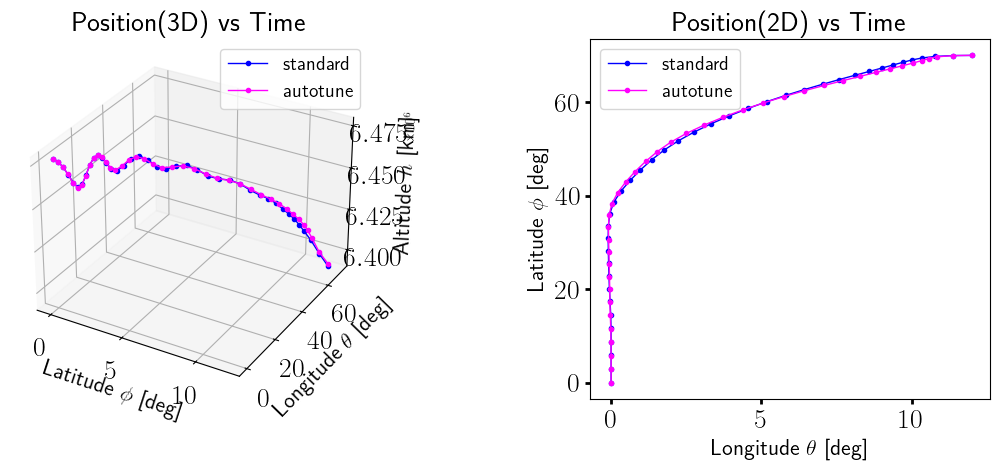

In [7]:
params = {}
params['displayfigs'] = True;
makePlotTrajs(PLTS1,ins={**plotparams,**params});

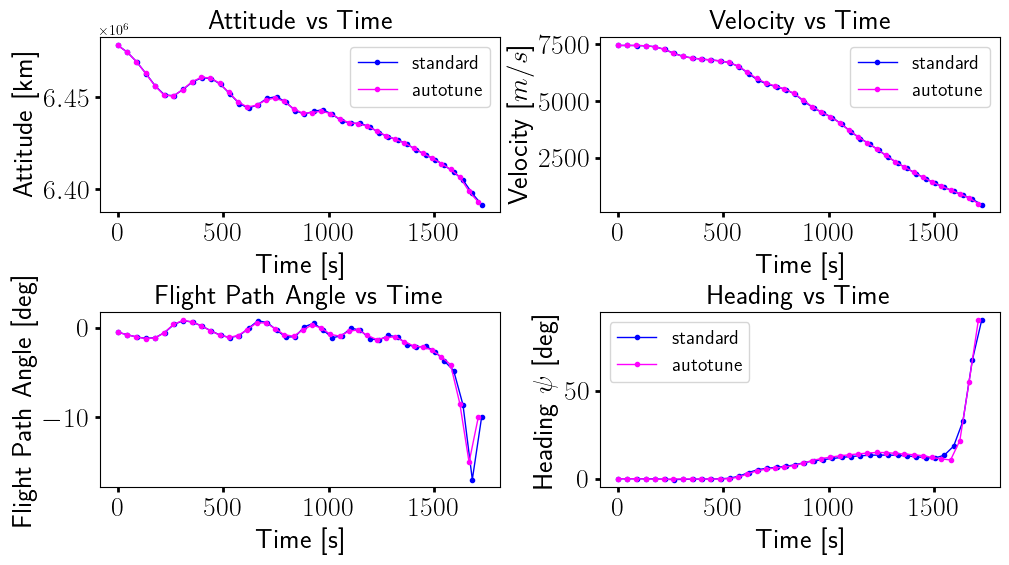

In [8]:
params = {}
figsize = (10,5);
grid = {};
grid[0] = [0.05,0.6,0.4,0.35];  grid[1] = [0.55,0.6,0.4,0.35];
grid[2] = [0.05,0.05,0.4,0.35]; grid[3] = [0.55,0.05,0.4,0.35];
   
titles = {};
ylabels = {};
xlabels = {ind:'Time [s]' for ind in range(4)};
titles[0] = 'Attitude vs Time';
titles[1] = 'Velocity vs Time';
titles[2] = 'Flight Path Angle vs Time';
titles[3] = 'Heading vs Time';

ylabels[0] = 'Attitude [km]';
ylabels[1] = 'Velocity [$m/s$]';    
ylabels[2] = 'Flight Path Angle [deg]';
ylabels[3] = 'Heading $\psi$ [deg]';

params['titleinfo'] = {'fontsize':20,}
params['xlabelinfo'] = {'fontsize':20}
params['ylabelinfo'] = {'fontsize':20}
# params['ticksinfo'] = {'fontsize':20}
# params['legendinfo'] = {'fontsize':2}
params['uselegend'] = [0,1,3];

params['figsize'] = figsize; params['grid'] = grid;
params['titles'] = titles; params['xlabels'] = xlabels; params['ylabels'] = ylabels;
params['displayfigs'] = True;

makePlotStates(PLTS1,ins={**plotparams,**params});

In [9]:
# temp = data['scenario1']['autotune']['mc_data'][0]['iters'][2]['weights'];#params']['method']['weights']['W_dyn'];
temp = data['scenario1']['autotune']['mc_data'][0]['iters'][2]['conv_data'];#['chk_feas_ineq'];#params']['method']['weights']['W_dyn'];
# ['w_cost', 'alpha_z', 'alpha_u', 'beta', 'gamma', 'eps_nonzero1',
#  'eps_nonzero2', 'wbuff', 'w_path_scale', 'w_custom_scale', 'w_nfz_scale',
#  'w_dyn_scale', 'w_term_scale',

#  'W_ineq', 'W_term', 'W_dyn', 'W_plus','W_minus',
#  'dual_ineq', 'dual_term', 'dual_dyn', 'dual_plus', 'dual_minus',

#  'wtr_z', 'wtr_u', 'w_fac_N', 'w_fac_Nm1', 'w_ctcs', 'data']


# print(temp)
# print(list(temp))
# print(temp['W_ineq'])

In [10]:

temp = data['scenario1']['autotune']['mc_data'][1]['iters'][-1]['weights'];
# print(temp['weights']['W_ineq'])
print(temp['W_ineq'].shape)
inds = problem.indices.constraints.nonlinear_inequality['path']; #))
# plt.plot(temp['W_ineq'][:,inds])

(40, 5)


In [11]:
# temp = data['scenario1']['autotune']['mc_data'][1]['iters'][-1]['weights'];
# print(list(temp))# print(temp['weights']['W_ineq'])
# print(temp['W_minus_ctcs'])
# print(temp['W_ineq'].shape)
# inds = problem.indices.constraints.nonlinear_inequality['path']; #))
# # plt.plot(temp['W_ineq'][:,inds])

# temp = problem.method.subprob.iter_data[0]['conv_data']

# # print(list(PLTS1.data['scenario1']['method']))

# print(list(temp))
# print(temp['chk_feas_term'])